In [1]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import pyvista as pv
from desmin_reconstruction.plotting import line_and_bandplot
from desmin_reconstruction.plotting.renderings import render_pointcloud
from desmin_reconstruction.preprocessing.bbox import BoundingSquare, filter_bounded
from desmin_reconstruction.voronoi import random_uniform_like, VoronoiAnalysis
from tqdm import tqdm
import scipy.spatial as scspatial
from jaxtyping import Float, Int
import scipy.sparse as scsparse
import colorcet as cc
import polars as pl
import alphashape


plt.rc("font", size=12)
plt.rc("grid", linestyle="--", color="lightgray")
plt.rc("axes.spines", right=False, top=False)
pv.set_jupyter_backend("static")

COLOR_DICT = {"desmin": "#FF0000", "actinin": "#00FF00"}

In [3]:
df = pl.read_csv("../data/results/desmin_alphaactinin_600nm_aligned.csv")
points = {
    name: df_.select(["x", "y", "z"]).to_numpy()
    for name, df_ in zip(("desmin", "actinin"), df.partition_by("probe"))
}

In [4]:
bbox = BoundingSquare(6, 0, side=12.5)
points_roi = {k: filter_bounded(v, bbox) for k, v in points.items()}

In [9]:
shape = alphashape.alphashape(points_roi["actinin"], alpha=0.0)

In [86]:
alphas = np.logspace(2, 6, 10, base=2.0)
vol_alphas = []
for a in tqdm(alphas):
    m=alphashape.alphashape(points_roi["actinin"], alpha=a)
    vol_alphas.append(m.area)

100%|██████████| 10/10 [06:23<00:00, 38.40s/it]


In [87]:
vol_alphas

[np.float64(72.09731361438251),
 np.float64(48.79304590356083),
 np.float64(37.956743406461456),
 np.float64(32.9242277398905),
 np.float64(30.540344143839988),
 np.float64(28.689104131049447),
 np.float64(26.078498375114528),
 np.float64(21.71616327732937),
 np.float64(15.926744494660033),
 np.float64(9.98096539051781)]

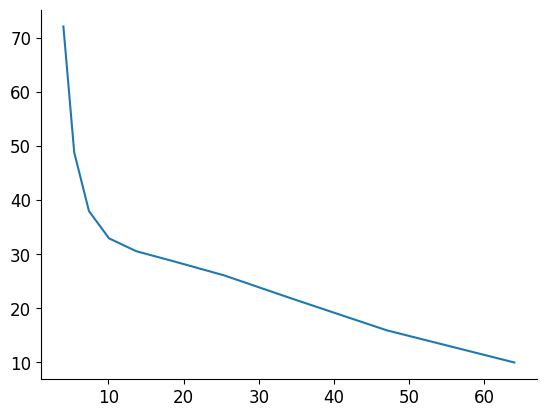

In [88]:
plt.plot(alphas, vol_alphas)

In [95]:
alphas = np.logspace(2, 6, 10, base=2.0)
vol_alphas = []
for a in tqdm(alphas):
    m=alphashape.alphashape(points_roi["desmin"], alpha=a)
    vol_alphas.append(m.area)

100%|██████████| 10/10 [02:37<00:00, 15.74s/it]


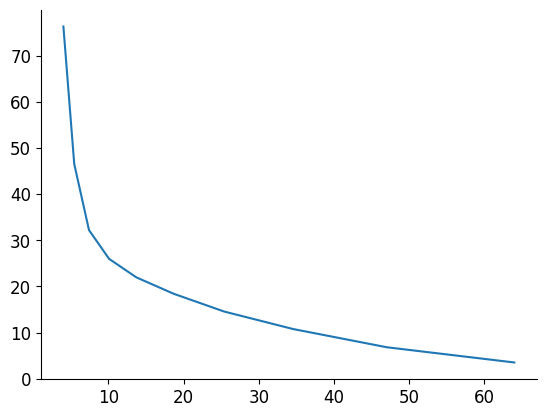

In [96]:
plt.plot(alphas, vol_alphas)

In [97]:
from kneed import KneeLocator
kl = KneeLocator(alphas, np.asarray(vol_alphas), curve="convex", direction="decreasing")
kl.knee

np.float64(10.079368399158984)

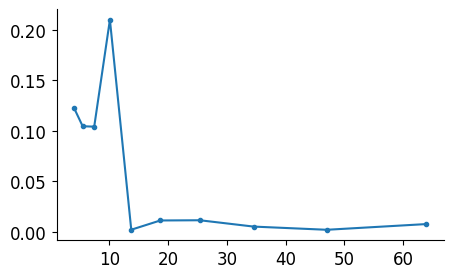

In [53]:
fig, ax = plt.subplots(1,1, figsize = (5, 3))
ax.plot(alphas, vol_alphas, ".-")
#ax.set_xscale("log")


In [5]:
mesh_actinin = pv.wrap(alphashape.alphashape(points_roi["actinin"], alpha=10))
mesh_desmin = pv.wrap(alphashape.alphashape(points_roi["desmin"], alpha=10))

In [6]:
mesh_actinin.volume

0.01547091588148988

2026-07-01 00:26:32.493 (  69.686s) [    15315516B740]vtkXOpenGLRenderWindow.:1416  WARN| bad X server connection. DISPLAY=


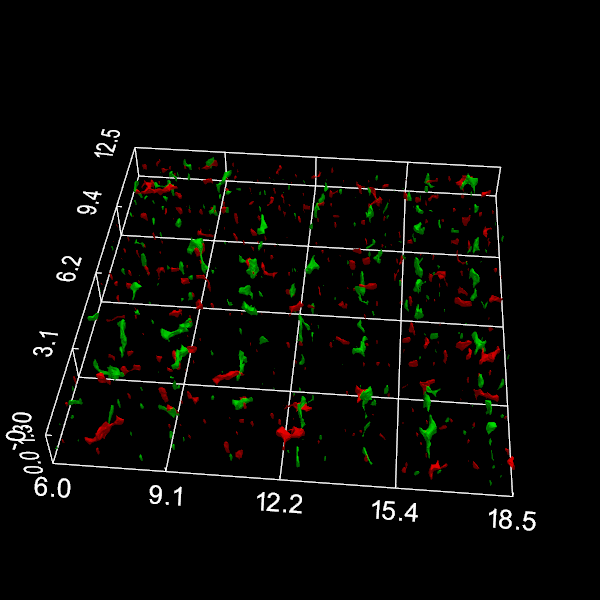

In [7]:
p = pv.Plotter(notebook=True, window_size=(600, 600))
p.add_mesh(
    mesh_desmin.smooth_taubin(10),
    color="#FF0000",
    show_scalar_bar=False,
)

p.add_mesh(
    mesh_actinin.smooth_taubin(10),
    color="#00FF00",
    show_scalar_bar=False,
)
p.set_background("black")
# pl.view_xy()
axis = p.show_bounds(
    color="white",
    # bounds=[0.0, 8.0, 0.0, 8.0, 0.0, 2.0],
    grid="back",
    bold=False,
    font_size=20,
    location="outer",
    font_family="arial",
    padding=0.0,
    use_3d_text=False,
    n_zlabels=2,
    xtitle="",
    ytitle="",
    ztitle="",
    ticks="inside",
)
p.camera.azimuth = 230
p.camera.elevation =10
# pl.camera.zoom(0.8)
p.show()
p.save_graphic("../figures/fig_4/4g.svg")

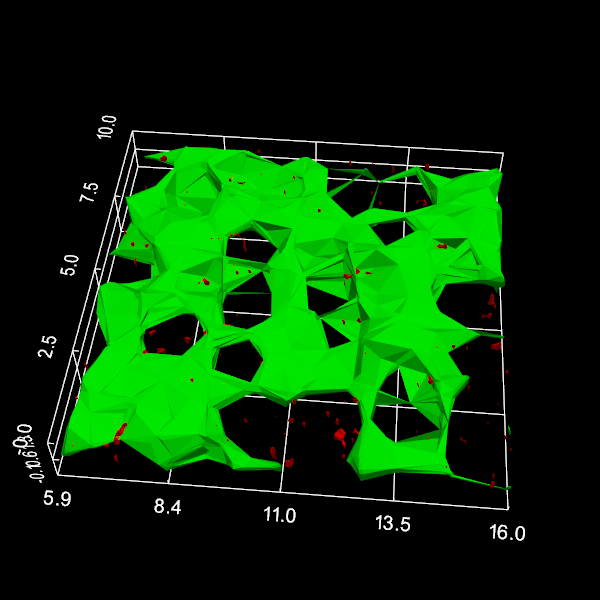

In [464]:
pl = pv.Plotter(notebook=True, window_size=(600, 600))
pl.add_mesh(
    mesh_desmin.smooth_taubin(n_iter=10),
    color="#FF0000",
    show_scalar_bar=False,
)

pl.add_mesh(
    mesh_actinin.smooth_taubin(n_iter=10),
    color="#00FF00",
    show_scalar_bar=False,
    opacity=1.0,
)
pl.set_background("black")
# pl.view_xy()
axis = pl.show_bounds(
    color="white",
    # bounds=[0.0, 8.0, 0.0, 8.0, 0.0, 2.0],
    grid="back",
    bold=False,
    font_size=15,
    location="outer",
    font_family="arial",
    padding=0.0,
    use_3d_text=False,
    n_zlabels=3,
    xtitle="",
    ytitle="",
    ztitle="",
    ticks="inside",
)
pl.camera.azimuth = 230
pl.camera.elevation = 15
# pl.camera.zoom(0.8)
pl.show()

In [365]:
x0s = (2, 6, 10, 14, 18, 1, 5, 9, 13, 17, 0, 4, 8, 12, 16, 15)
y0s = (9, 9, 9, 9, 9, 5, 5, 5, 5, 5, 1, 1, 1, 1, 1, -3)
bboxes = [BoundingSquare(x0, y0, side=4) for x0, y0 in zip(x0s, y0s)]

In [ ]:
# bbox = bboxes[12]#BoundingSquare(6, 0, side=5)
points_test = {k: filter_bounded(v, bbox) for k, v in points.items()}

In [ ]:
shape = alphashape.alphashape(points_test["actinin"], alpha=8.0)

In [ ]:
alpha = optimizealpha(points_test["actinin"], upper=10, max_iterations=10)

maximum allowed iterations reached while optimizing the alpha parameter


In [431]:
alpha

1.5673828125

In [349]:
shape

<trimesh.Trimesh(vertices.shape=(3036, 3), faces.shape=(5954, 3))>

In [350]:
type(shape)

trimesh.base.Trimesh

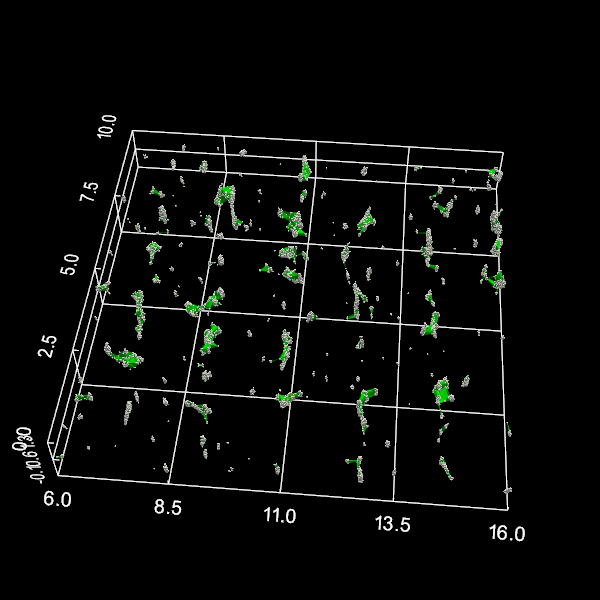

In [13]:
p = pv.Plotter(notebook=True, window_size=(600, 600))
# p.add_mesh(
#     mesh_desmin,
#     color="#FF0000",
#     show_scalar_bar=False,
# )
p.add_mesh(
    pv.wrap(points_test["actinin"]),
    color="white",
    render_points_as_spheres=True,
    point_size=2,
    show_scalar_bar=False,
)
p.add_mesh(
    pv.wrap(shape),
    color="#00FF00",
    show_scalar_bar=False,
)
p.set_background("black")
# pl.view_xy()
axis = p.show_bounds(
    color="white",
    # bounds=[0.0, 8.0, 0.0, 8.0, 0.0, 2.0],
    grid="back",
    bold=False,
    font_size=15,
    location="outer",
    font_family="arial",
    padding=0.0,
    use_3d_text=False,
    n_zlabels=3,
    xtitle="",
    ytitle="",
    ztitle="",
    ticks="inside",
)
p.camera.azimuth = 230
p.camera.elevation = 15
# pl.camera.zoom(0.8)
p.show()

In [70]:
def group_nearby_points(
    points: Float[np.ndarray, "N D"], distance_threshold: float
) -> tuple[int, Int[np.ndarray, "N D"]]:
    tree = scspatial.KDTree(points)
    adjacency = (
        tree.sparse_distance_matrix(
            tree, max_distance=distance_threshold, output_type="coo_matrix"
        )
        > 0
    )
    n_comp, labels = scsparse.csgraph.connected_components(adjacency, directed=False)
    return n_comp, labels

In [71]:
lengths = [np.sum(labels == i) for i in range(n_comp)]
np.sum(np.asarray(lengths) > 10)

NameError: name 'n_comp' is not defined

In [74]:
n_comp, labels = group_nearby_points(points_roi["actinin"], 0.1)
pts = pv.wrap(points_roi["actinin"])
pts.point_data["cluster_id"] = labels
pts

PolyData (0x1534e50d9d20)
  N Cells:    61113
  N Points:   61113
  N Strips:   0
  X Bounds:   6.000e+00, 1.850e+01
  Y Bounds:   2.919e-05, 1.250e+01
  Z Bounds:   -6.475e-02, 1.295e+00
  N Arrays:   1

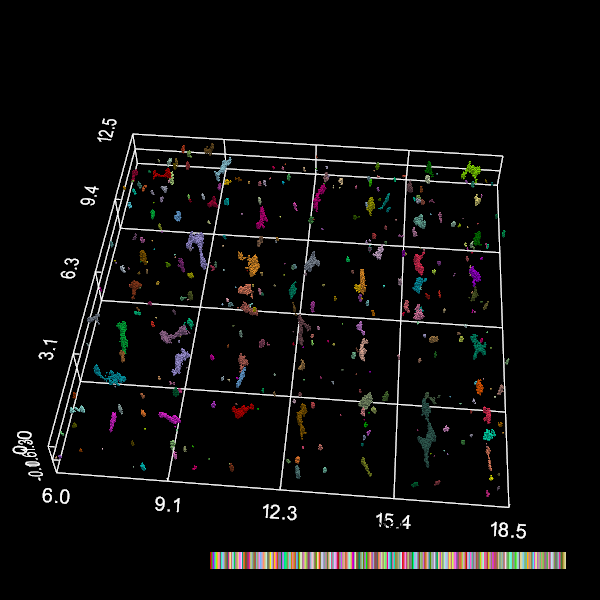

In [75]:
import colorcet as cc

p = pv.Plotter(notebook=True, window_size=(600, 600))
# p.add_mesh(
#     mesh_desmin,
#     color="#FF0000",
#     show_scalar_bar=False,
# )
p.add_mesh(
    pts,
    scalars="cluster_id",
    cmap=cc.cm.glasbey_light,
    render_points_as_spheres=True,
    point_size=2,
)
# p.add_mesh(
#     pv.wrap(shape),
#     color="#00FF00",
#     show_scalar_bar=False,
# )
p.set_background("black")
# pl.view_xy()
axis = p.show_bounds(
    color="white",
    # bounds=[0.0, 8.0, 0.0, 8.0, 0.0, 2.0],
    grid="back",
    bold=False,
    font_size=15,
    location="outer",
    font_family="arial",
    padding=0.0,
    use_3d_text=False,
    n_zlabels=3,
    xtitle="",
    ytitle="",
    ztitle="",
    ticks="inside",
)
p.camera.azimuth = 230
p.camera.elevation = 15
# pl.camera.zoom(0.8)
p.show()

In [76]:
import sys
import trimesh


def _testalpha(points: list[tuple[float]] | np.ndarray, alpha: float):
    """
    Evaluates an alpha parameter.

    This helper function creates an alpha shape with the given points and alpha
    parameter.  It then checks that the produced shape is a Polygon and that it
    intersects all the input points.

    Args:
        points: data points
        alpha: alpha value

    Returns:
        bool: True if the resulting alpha shape is a single polygon that
            intersects all the input data points.
    """

    polygon = alphashape.alphashape(points, alpha)

    return (
        len(polygon.faces) > 0
        and all(trimesh.proximity.signed_distance(polygon, list(points)) >= 0)
        and polygon.is_watertight
    )


def optimizealpha(
    points: list[tuple[float]] | np.ndarray,
    max_iterations: int = 10000,
    lower: float = 0.0,
    upper: float = 1000,
    silent: bool = False,
    tol=1e-4,
):
    """
    Solve for the alpha parameter.

    Attempt to determine the alpha parameter that best wraps the given set of
    points in one polygon without dropping any points.

    Note:  If the solver fails to find a solution, a value of zero will be
    returned, which when used with the alphashape function will safely return a
    convex hull around the points.

    Args:

        points: an iterable container of points
        max_iterations (int): maximum number of iterations while finding the
            solution
        lower: lower limit for optimization
        upper: upper limit for optimization
        silent: silence warnings

    Returns:

        float: The optimized alpha parameter

    """

    # Set the bounds
    assert lower >= 0, "The lower bounds must be at least 0"
    # Ensure the upper limit bounds the solution
    assert upper <= sys.float_info.max, (
        f"The upper bounds must be less than or equal to {sys.float_info.max} "
        "on your system"
    )

    if _testalpha(points, upper):
        if not silent:
            raise ValueError(
                "the max float value does not bound the alpha parameter solution"
            )

    # Begin the bisection loop
    counter = 0
    while (upper - lower) > tol:
        # Bisect the current bounds
        test_alpha = (upper + lower) * 0.5

        # Update the bounds to include the solution space
        if _testalpha(points, test_alpha):
            lower = test_alpha
        else:
            upper = test_alpha

        # Handle exceeding maximum allowed number of iterations
        counter += 1
        if counter > max_iterations:
            print(
                "maximum allowed iterations reached while "
                "optimizing the alpha parameter"
            )
            break
    return lower

In [78]:
points_roi["actinin"][labels == 8].shape

(1557, 3)

In [80]:
for id in tqdm(range(n_comp)):
    cluster = points_roi["actinin"][labels == id]
    print(id, len(cluster))

100%|██████████| 390/390 [00:00<00:00, 5781.75it/s]

0 602
1 1058
2 593
3 858
4 1355
5 1577
6 717
7 948
8 1557
9 1499
10 708
11 517
12 1345
13 426
14 2009
15 1740
16 1368
17 1792
18 1942
19 2703
20 1738
21 1280
22 791
23 668
24 436
25 881
26 1274
27 716
28 1073
29 1218
30 122
31 684
32 1083
33 944
34 692
35 742
36 586
37 401
38 259
39 782
40 549
41 74
42 181
43 802
44 1026
45 93
46 885
47 275
48 428
49 128
50 360
51 567
52 609
53 165
54 456
55 492
56 415
57 80
58 82
59 398
60 17
61 134
62 187
63 7
64 20
65 140
66 26
67 28
68 101
69 258
70 47
71 113
72 29
73 13
74 1
75 674
76 106
77 35
78 76
79 214
80 23
81 492
82 57
83 50
84 79
85 189
86 231
87 293
88 168
89 80
90 2
91 145
92 14
93 118
94 159
95 7
96 120
97 69
98 1
99 1
100 348
101 86
102 1
103 95
104 42
105 187
106 91
107 21
108 26
109 13
110 27
111 7
112 2
113 70
114 30
115 12
116 34
117 107
118 38
119 15
120 22
121 36
122 60
123 38
124 57
125 172
126 4
127 24
128 111
129 5
130 7
131 10
132 110
133 2
134 99
135 105
136 37
137 21
138 8
139 7
140 40
141 1
142 13
143 3
144 102
145 6
146 7

In [83]:
meshes = []
n_comp, labels = group_nearby_points(points_roi["actinin"], 0.1)
for id in tqdm(range(n_comp)):
    cluster = points_roi["actinin"][labels == id]
    if len(cluster) <= 10:
        continue
    try:
        alpha = optimizealpha(cluster, upper=50, max_iterations=10)
        print(id, alpha)
        meshes.append(alphashape.alphashape(cluster, alpha))
    except IndexError:
        continue

  0%|          | 0/390 [00:00<?, ?it/s]

maximum allowed iterations reached while optimizing the alpha parameter
0 4.5654296875


  0%|          | 1/390 [00:05<33:45,  5.21s/it]

maximum allowed iterations reached while optimizing the alpha parameter
1 12.0849609375


  1%|          | 2/390 [00:14<50:12,  7.76s/it]

...

maximum allowed iterations reached while optimizing the alpha parameter
19 1.0986328125


  5%|▌         | 20/390 [03:46<1:47:27, 17.43s/it]

maximum allowed iterations reached while optimizing the alpha parameter
20 13.6962890625


  5%|▌         | 21/390 [04:08<1:12:42, 11.82s/it]


KeyboardInterrupt: 

In [ ]:
mesh_total = trimesh.util.concatenate(meshes)

In [ ]:
n_comp, labels = group_nearby_points(points_test["desmin"], 0.1)
meshes_desmin = []
for id in tqdm(range(n_comp)):
    cluster = points_test["desmin"][labels == id]
    if len(cluster) <= 10:
        continue
    try:
        alpha = optimizealpha(cluster, upper=100, max_iterations=10)
        print(id, alpha)
        meshes_desmin.append(alphashape.alphashape(cluster, alpha))
    except IndexError:
        continue

  1%|          | 3/311 [00:01<03:21,  1.53it/s]

maximum allowed iterations reached while optimizing the alpha parameter
2 12.158203125


  1%|▏         | 4/311 [00:03<05:07,  1.00s/it]

maximum allowed iterations reached while optimizing the alpha parameter
3 12.939453125
maximum allowed iterations reached while optimizing the alpha parameter
5 5.17578125


  2%|▏         | 6/311 [00:08<08:14,  1.62s/it]

...

maximum allowed iterations reached while optimizing the alpha parameter
262 62.40234375
maximum allowed iterations reached while optimizing the alpha parameter
275 18.45703125


 91%|█████████ | 283/311 [01:53<00:00, 32.43it/s]

maximum allowed iterations reached while optimizing the alpha parameter
281 18.994140625


100%|██████████| 311/311 [01:53<00:00,  2.74it/s]

maximum allowed iterations reached while optimizing the alpha parameter
286 39.306640625


In [ ]:
mesh_total_desmin = trimesh.util.concatenate(meshes_desmin)

In [ ]:
pv.wrap(meshes[2]).subdivide(2, "loop")
meshes[2].is_watertight

True

In [144]:
meshes_pv = [pv.wrap(m).subdivide(2) for m in tqdm(meshes)]

  0%|          | 0/70 [00:00<?, ?it/s]ERROR:root:Dataset is non-manifold and cannot be subdivided.
2026-06-22 20:43:29.581 (9359.154s) [    15317AB07740]vtkLinearSubdivisionFil:69     ERR| vtkLinearSubdivisionFilter (0x152fc1ca5870): Dataset is non-manifold and cannot be subdivided.
ERROR:root:Subdivision failed.
2026-06-22 20:43:29.582 (9359.155s) [    15317AB07740]vtkInterpolatingSubdivi:90     ERR| vtkLinearSubdivisionFilter (0x152fc1ca5870): Subdivision failed.
ERROR:root:Algorithm vtkLinearSubdivisionFilter (0x152fc1ca5870) returned failure for request: vtkInformation (0x152fc1f441b0)
2026-06-22 20:43:29.582 (9359.155s) [    15317AB07740]       vtkExecutive.cxx:729    ERR| vtkCompositeDataPipeline (0x152fc1c67f70): Algorithm vtkLinearSubdivisionFilter (0x152fc1ca5870) returned failure for request: vtkInformation (0x152fc1f441b0)
  Debug: Off
  Modified Time: 7910392
  Reference Count: 1
  Registered Events: (none)
  Request: REQUEST_DATA
  FROM_OUTPUT_PORT: 0
  ALGORITHM_AFTER_FOR

True

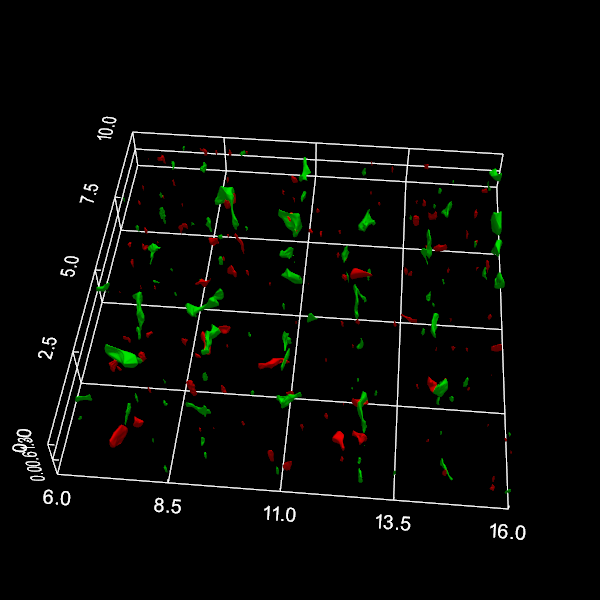

In [ ]:
p = pv.Plotter(notebook=True, window_size=(600, 600))
p.add_mesh(
    pv.wrap(mesh_total_desmin).subdivide(2, "loop"),
    color="#FF0000",
    show_scalar_bar=False,
)
# p.add_mesh(
#     pv.wrap(points_test["actinin"]),
#     color="white",
#     render_points_as_spheres=True,
#     point_size=1,
#     show_scalar_bar=False,
# )
p.add_mesh(
    pv.wrap(mesh_total).subdivide(2, "loop"),
    color="#00FF00",
    show_scalar_bar=False,
)
p.set_background("black")
# pl.view_xy()
axis = p.show_bounds(
    color="white",
    # bounds=[0.0, 8.0, 0.0, 8.0, 0.0, 2.0],
    grid="back",
    bold=False,
    font_size=15,
    location="outer",
    font_family="arial",
    padding=0.0,
    use_3d_text=False,
    n_zlabels=3,
    xtitle="",
    ytitle="",
    ztitle="",
    ticks="inside",
)
p.camera.azimuth = 230
p.camera.elevation = 15
# pl.camera.zoom(0.8)
p.show()

In [ ]:
meshes2 = []
n_comp, labels = group_nearby_points(points_test["actinin"], 0.3)
for id in tqdm(range(n_comp)):
    cluster = points_test["actinin"][labels == id]
    if len(cluster) <= 20:
        continue
    try:
        meshes2.append(alphashape.alphashape(cluster, 8))
    except IndexError:
        continue

100%|██████████| 140/140 [00:23<00:00,  5.97it/s] 


In [ ]:
meshes2_desmin = []
n_comp, labels = group_nearby_points(points_test["desmin"], 0.3)
for id in tqdm(range(n_comp)):
    cluster = points_test["desmin"][labels == id]
    if len(cluster) <= 20:
        continue
    try:
        meshes2_desmin.append(alphashape.alphashape(cluster, 8))
    except IndexError:
        continue

100%|██████████| 154/154 [00:08<00:00, 17.77it/s]


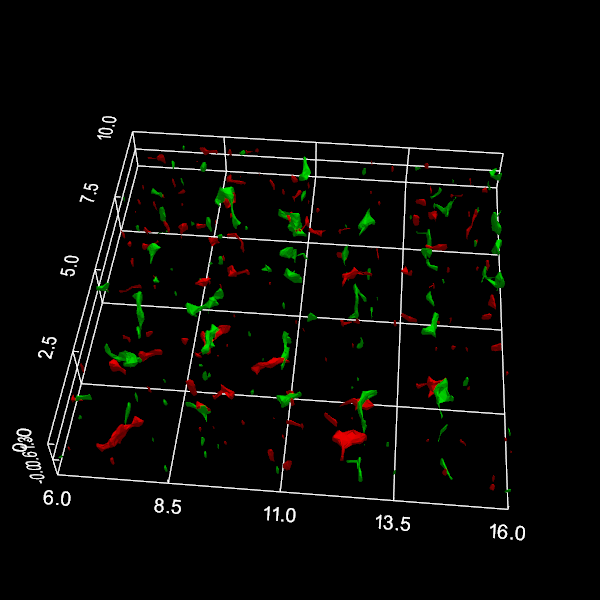

In [78]:
p = pv.Plotter(notebook=True, window_size=(600, 600))
p.add_mesh(
    pv.wrap(trimesh.util.concatenate(meshes2_desmin)).extract_surface().smooth(30),
    color="#FF0000",
    show_scalar_bar=False,
    opacity=1.0,
)
# p.add_mesh(
#     pv.wrap(points_test["actinin"]),
#     color="white",
#     render_points_as_spheres=True,
#     point_size=1,
#     show_scalar_bar=False,
# )
p.add_mesh(
    pv.wrap(trimesh.util.concatenate(meshes2)).extract_surface().smooth(50),
    color="#00FF00",
    show_scalar_bar=False,
    opacity=1.0,
)
p.set_background("black")
# pl.view_xy()
axis = p.show_bounds(
    color="white",
    # bounds=[0.0, 8.0, 0.0, 8.0, 0.0, 2.0],
    grid="back",
    bold=False,
    font_size=15,
    location="outer",
    font_family="arial",
    padding=0.0,
    use_3d_text=False,
    n_zlabels=3,
    xtitle="",
    ytitle="",
    ztitle="",
    ticks="inside",
)
p.camera.azimuth = 230
p.camera.elevation = 15
# pl.camera.zoom(0.8)
p.show()

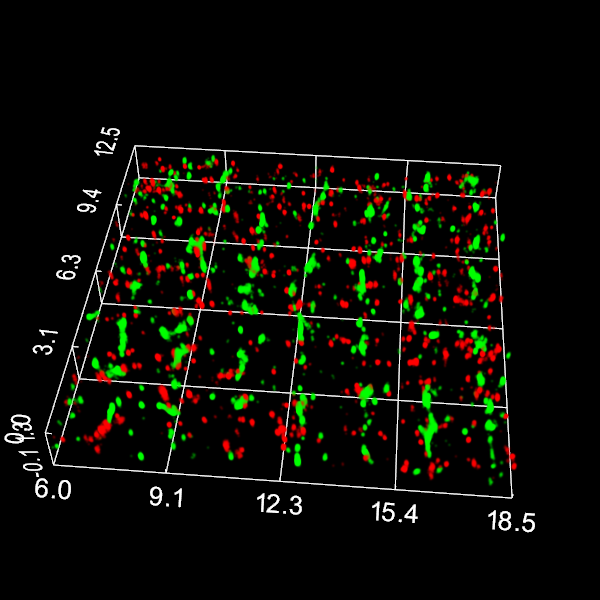

In [8]:
import colorcet as cc

p = pv.Plotter(notebook=True, window_size=(600, 600))
p.add_mesh(
    points_roi["actinin"],
    color="#00FF00",
    show_scalar_bar=False,
    style="points_gaussian",
    # emissive=True,
    point_size=2,
    opacity=0.2,
)
p.add_mesh(
    points_roi["desmin"],
    # scalars="cluster_id",
    color="#FF0000",
    style="points_gaussian",
    # emissive=True,
    point_size=2,
    opacity=0.2,
)
# p.add_mesh(
#     pv.wrap(shape),
#     color="#00FF00",
#     show_scalar_bar=False,
# )
p.set_background("black")
# pl.view_xy()
axis = p.show_bounds(
    color="white",
    # bounds=[0.0, 8.0, 0.0, 8.0, 0.0, 2.0],
    grid="back",
    bold=False,
    font_size=20,
    location="outer",
    font_family="arial",
    padding=0.0,
    use_3d_text=False,
    n_zlabels=2,
    xtitle="",
    ytitle="",
    ztitle="",
    ticks="inside",
)
p.camera.azimuth = 230
p.camera.elevation = 10
# pl.camera.zoom(0.8)
p.show()
p.save_graphic("../figures/fig_4/4f.svg")

In [132]:
cluster.shape

(3,)

False


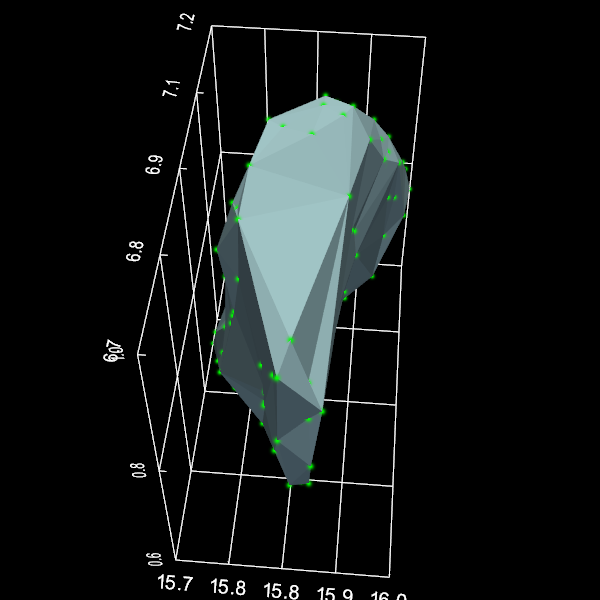

In [ ]:
mesh_idx = 2
n_comp, labels = group_nearby_points(points_test["actinin"], 0.3)
cluster = points_test["actinin"][labels == mesh_idx]
p = pv.Plotter(notebook=True, window_size=(600, 600))
p.add_mesh(
    pv.wrap(cluster),
    color="#00FF00",
    show_scalar_bar=False,
    style="points_gaussian",
    # emissive=True,
    point_size=4,
    opacity=1.0,
)
m = alphashape.alphashape(cluster, 15)
print(m.is_watertight)
p.add_mesh(
    pv.wrap(meshes[2]),  # .subdivide(2,"loop"),
    # color="#00FF00",
    # show_scalar_bar=False,
    # style="points_gaussian",
    #     # emissive=True,
    # point_size=2,
    # opacity=1.0,
)
p.set_background("black")
# pl.view_xy()
axis = p.show_bounds(
    color="white",
    # bounds=[0.0, 8.0, 0.0, 8.0, 0.0, 2.0],
    grid="back",
    bold=False,
    font_size=15,
    location="outer",
    font_family="arial",
    padding=0.0,
    use_3d_text=False,
    n_zlabels=3,
    xtitle="",
    ytitle="",
    ztitle="",
    ticks="inside",
)
p.camera.azimuth = 230
p.camera.elevation = 15
# pl.camera.zoom(0.8)
p.show()

In [ ]:
surf = pv.wrap(cluster).reconstruct_surface()